# Stage 6 — Earth pair and label generation

_Pipeline stage 6 of `docs/PIPELINE_DESIGN.md`. Uses the canonical `channel_heads` package + on-disk artifacts; heavy rebuilds run via the `channel-heads` CLI (see each stage's command)._

## Pairs, the touching label, and what separates the classes

For every outlet we take **first-meet pairs** of channel heads (the two heads that
first meet going downstream at a confluence). The label `y = touching` is a geometric
test: do the heads' contributing pixels touch (8-connectivity)? Trivial negatives are
removed (`filter_hard_negatives`) and negatives subsampled to ~3:1.

Below: per-regime class balance, then the **distributions of the 5 model features**
for touching vs non-touching — the signal the classifier exploits.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import channel_heads as ch
from channel_heads.io.paths import PROJECT_ROOT, RESULTS_DIR, EXAMPLE_DEMS
ROOT     = PROJECT_ROOT
MODELS   = ROOT / 'models'
MARS_OUT = ROOT / 'data/Mars/model_outputs'
MARS_IN  = ROOT / 'data/Mars/model_inputs'
REGIMES_ = ['regA', 'regB', 'regC']
# Frozen model features (5 dimensionless) + operating thresholds (Stage 9).
MODEL_FEATURES = ['orientation_diff_deg','headhead_dist_norm','apex_angle_deg',
                  'strahler_order_diff','proximity_profile_norm']
OP_THR = {'regA': 0.756326, 'regB': 0.779264, 'regC': 0.759369}
print('channel_heads', ch.__version__, '| root', ROOT)


channel_heads 0.1.0 | root /Users/guypi/Projects/channel-heads


In [2]:
rows = []
for r in REGIMES_:
    p = RESULTS_DIR / f'master_dataset_{r}.csv'
    if p.exists():
        d = pd.read_csv(p)
        rows.append({'regime': r, 'pairs': len(d), 'touching': int(d.y.sum()),
                     'touching_%': round(100*d.y.mean(), 1), 'basins': d.basin.nunique()})
pd.DataFrame(rows)

,regime,pairs,touching,touching_%,basins
0,regA,25916,7523,29.0,17
1,regB,11573,3576,30.9,17
2,regC,31056,7764,25.0,17


### Feature separation (regA): touching vs non-touching

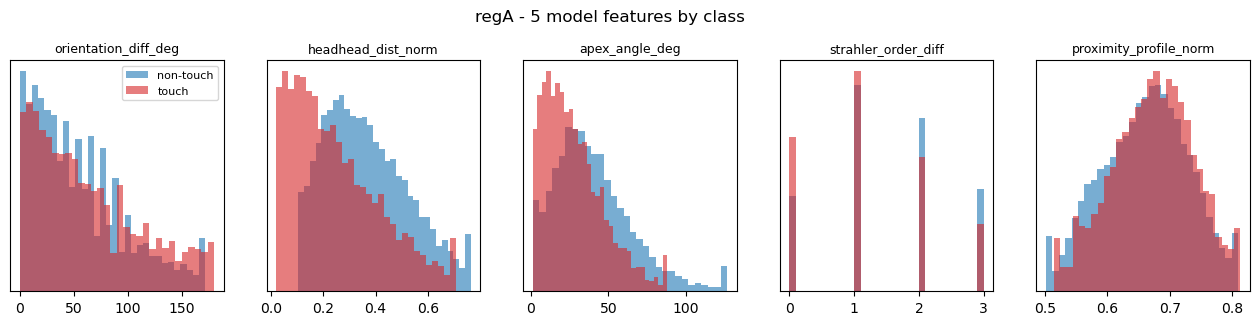

In [3]:
d = pd.read_csv(RESULTS_DIR / 'master_dataset_regA.csv')
fig, axes = plt.subplots(1, len(MODEL_FEATURES), figsize=(16, 3))
for ax, feat in zip(axes, MODEL_FEATURES):
    for lbl, col, name in [(0, '#1f77b4', 'non-touch'), (1, '#d62728', 'touch')]:
        v = d.loc[d.y == lbl, feat].dropna()
        lo, hi = v.quantile([0.01, 0.99])
        ax.hist(v.clip(lo, hi), bins=30, alpha=0.6, color=col, density=True, label=name)
    ax.set_title(feat, fontsize=9); ax.set_yticks([])
axes[0].legend(fontsize=8); plt.suptitle('regA - 5 model features by class', y=1.05); plt.show()

Touching pairs trend toward smaller orientation contrast and shorter normalized
head–head distance — coupled heads sit closer and more aligned. No single feature
separates the classes, motivating a learned classifier + CNN shape context. Deep dive:
`notebooks/training/00_pair_sample_qa.ipynb` (renders actual pair geometries).